In [14]:
!pip install opencv-python
!pip install albumentations


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\tim58\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\tim58\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [ ]:
import matplotlib.pyplot as plt
import os
import json
import cv2
import numpy as np
import random

# Область интереса


Большинство фотографий, демонстрируемых пользователям, имеют размеры порядка 1000 пикселей. Соответственно при обучении желательно использовать фото сравнимых размеров.

На фотографиях нас в первую очередь интересуют логотипы, которые способен увидеть и распознать человек. Таким образом очень маленький логотип вряд ли привлечёт внимание пользователя и потому не является приоритетной целью для распознования. Полупрозрачный логотип с низким контрастом также представляет меньший интерес.  

Примеры нежелательного контента:
<table>
  <tr>
    <td><img src="img/autoru_1200x900n.webp" alt="Фото 1" style="width: 80%; height: auto;"></td>
    <td><img src="img/2838398372-1.jpg" alt="Фото 2" style="width: 80%; height: auto;"></td>
    <td><img src="img/drom1200.jpg" alt="Фото 2" style="width: 80%; height: auto;"></td>
  </tr>
    <tr>
    <td><img src="img/photo_5188261708810623308_y.jpg" alt="Фото 4" style="width: 80%; height: auto;"></td>
    <td><img src="img/photo_5188261708810623309_y.jpg" alt="Фото 5" style="width: 80%; height: auto;"></td>
    <td><img src="img/photo_5188261708810623304_y.jpg" alt="Фото 6" style="width: 80%; height: auto;"></td>
  </tr>
    <tr>
    <td><img src="img/photo_5188261708810623310_y.jpg" alt="Фото 7" style="width: 80%; height: auto;"></td>
    <td><img src="img/photo_5188261708810623311_y.jpg" alt="Фото 8" style="width: 80%; height: auto;"></td>
    <td><img src="img/photo_5188261708810623312_y.jpg" alt="Фото 9" style="width: 80%; height: auto;"></td>
  </tr>
</table>


# Анализ искомых логотипов.

Учитывая большой объем областей в которых работает Авито - существует множество конкурентов, появление логотипов которых в размещаемых объявлениях нежелательно.

Работа с запрещённой символикой принципиально не отличается от работы с логотипами конкурентов - нам надо её найти и распознать. Ориентируясь на тяжесть последствий от пропуска подобных символов можно изменить порог срабатывания модели для более жёсткой модерации или чаще подключать человека для решения спорных вопросов.




Ожидается что список нежелательных логотипов будет регулярно меняться(уход с рынка, появление на рынке, ребрендинг, новый закон), потому не обязательно создавать модель которая определит все и сразу - можно начать с небольшого количества логотипов, а затем постепенно увеличивать их количество. Выберем следующие логотипы конкурентов:

Посмотрим на логотипы конкурентов в некоторых областях:
1. Недвижимость - яндекс недвижимость, циан, домклик
<table>
  <tr align="center" valign="middle">
    <td style="width: 20%; text-align: center;"><img src="./logos/yandex-nedvizhimost-icon-logo.png" alt="ya_nedv" style="width: 20%; height: auto;"></td>
    <td style="width: 20%; text-align: center;"><img src="./logos/cian-sign-logo.png" alt="cian" style="width: 20%; height: auto;"></td>
    <td style="width: 20%; text-align: center;"><img src="./logos/domclick-sign-logo.png" alt="domclick" style="width: 20%; height: auto;"></td>
  </tr>
</table>

2. Жильё для путешествий:
<table>
  <tr align="center" valign="middle">
    <td style="width: 20%; text-align: center;"><img src="./logos/yandex-travel-icon-logo.png" alt="ya-tr" style="width: 20%; height: auto;"></td>
    <td style="width: 20%; text-align: center;"><img src="./logos/airbnb-icon-logo.png" alt="airbnb" style="width:20%; height: auto;"></td>
    <td style="width: 20%; text-align: center;"><img src="./logos/ostrovok.png" alt="ostrovok" style="width: 20%; height: auto;"></td>
  </tr>
</table>
3. Озон wildberries, яндекс маркет.
<table>
  <tr align="center" valign="middle">
    <td style="width: 20%; text-align: center;"><img src="./logos/ozon-icon-logo.png" alt="ozzi" style="width: 20%; height: auto;"></td>
    <td style="width: 20%; text-align: center;"><img src="./logos/wildberries-sign-logo.png" alt="berry" style="width:20%; height: auto;"></td>
    <td style="width: 20%; text-align: center;"><img src="./logos/yandex-market-sign-logo.png" alt="yammy" style="width: 20%; height: auto;"></td>
  </tr>
</table>



Отдельно хочется отметить что полупрозрачные логотипы наносимые на фото очень сильно отличаются по уровню прозрачности. И если логотип на фото с циана хорошо виден:

 <table>
        <tr>
            <td style="width: 40%; text-align: center;"><img src="img/2838398372-1.jpg" style="width: 80%; height: auto;"></td>
            <td style="width: 40%; text-align: center;"><img src="img/transparency_1.png" style="width: 80%; height: auto;"></td>
        </tr>
    </table>

То лого дром.ру почти не виден глазом:

<table>
  <tr>
    <td style="width: 40%; text-align: center;"><img src="img/drom1200.jpg" alt="Фото 1" style="width: 80%; height: auto;"></td>
    <td style="width: 40%; text-align: center;"><img src="img/transparency_2.webp" alt="Фото 2" style="width: 80%; height: auto;"></td>
  </tr>
</table>

Хотя можно попытаться списать на неудачный фон.

Что интересно - в просмотренных фото лого циана всегда в углу, а у drom.ru "мигрирует" по фотографии в зависимости от снимка.

Большинство конкурентов не являются производственными компаниями, потому их логотипы вряд ли будут представлены изображением физического носителя. 
(Разве что изображение на экране мобильного устройства или фото рекламного щита.)

Скорее всего это будет штамп поверх фото. Загрузка подобных фотографий должна вызвать подозрения в добросовестности пользователя.

Явное исключение составлют представители 3 пункта: тут вполне вероятно случайное появление в кадре вывески пункта выдачи, брендированного пакета, или упаковки, что вероятно, допустимо.


Итого: имеем 3 возможности появления нежелательных логотипов:
1) нанесение своего логотипа поверх фото, например авто.ру закрывает логотипом номера авто
2) Нанесение полупрозрачного логотипа, например, циан, дром 
3) Фото с логотипом на физическом носителе.

# Обзор имеющихся датасетов:

## 1. OSLD

Содержит около 20к изображений с 12к различных брендов представленных на них.

https://arxiv.org/abs/1911.07440

In [3]:
def show_boxes(image_dir, annotations):
    items = list(annotations.items())
    if len(items) == 1:
        fig, axes = plt.subplots(1, 1, figsize=(15, 5))
        axes = [axes]
    else:
        fig, axes = plt.subplots(1, len(items), figsize=(15, 5))
    
    for idx, (img_name, bboxes_data) in enumerate(items):
        img_path = os.path.join(image_dir, img_name)   
        img = cv2.imread(img_path)     
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        
        for bbox_data in bboxes_data:
            bbox = bbox_data[0]
            label = bbox_data[1]

            x1, y1, x2, y2 = bbox
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 145, 255), 5)
            cv2.putText(img, str(label), (x1, y2 + 25), 
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)
        
        axes[idx].imshow(img)
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

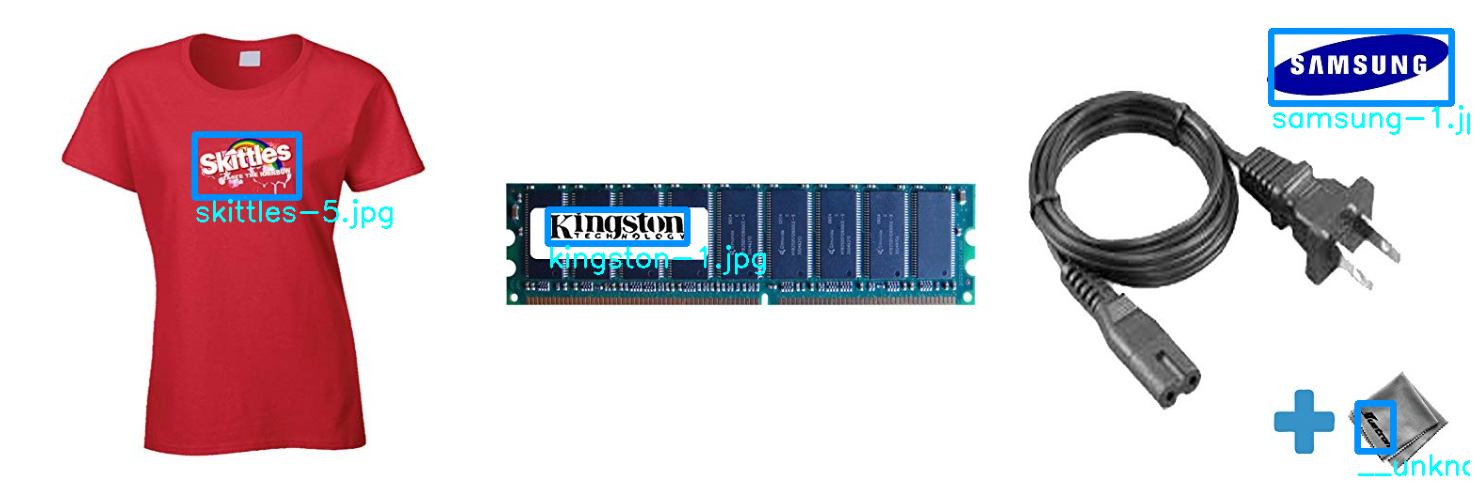

In [4]:
with open('./OSLD/osld-test.json', 'r') as f:
    annotations = json.load(f)

image_directory = "./OSLD" 
show_boxes(image_directory, annotations)

 Абсолютное большинство картинок представляет собой фото предмета с неким логотипом. Фон - белый.
Средний размер фото - до 500 пикс по высоте и ширине

## 2. LogoDet-3K


https://arxiv.org/abs/2008.05359

В датасет более 150к фото с 3к различных логотипов. Все фотографии разделены на 9 тематических групп. 

Встречается очень много фотографий, на которых просто изображён логотип:

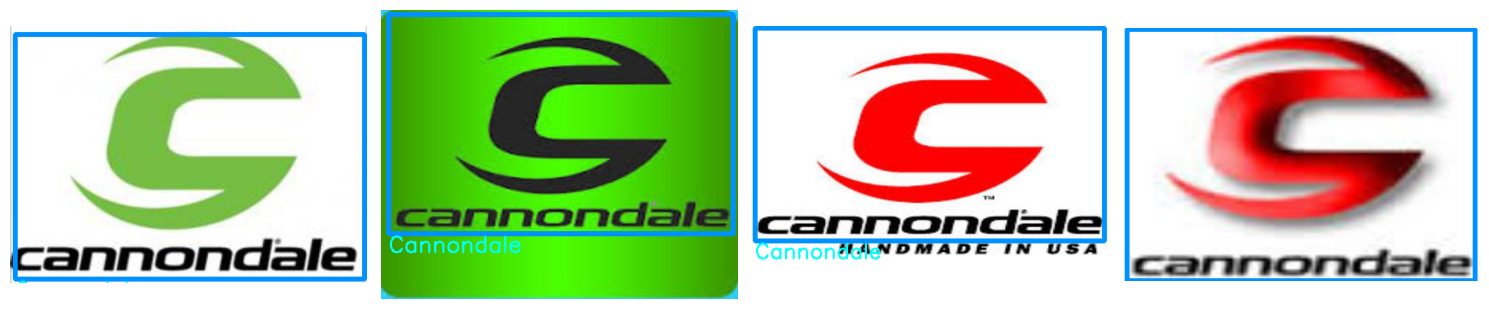

In [5]:
with open('./LOGO_DET/LOGO_DET.json', 'r') as f:
    annotations = json.load(f)

image_directory = "./LOGO_DET" 
show_boxes(image_directory, annotations)

Но также есть и "живые" фото

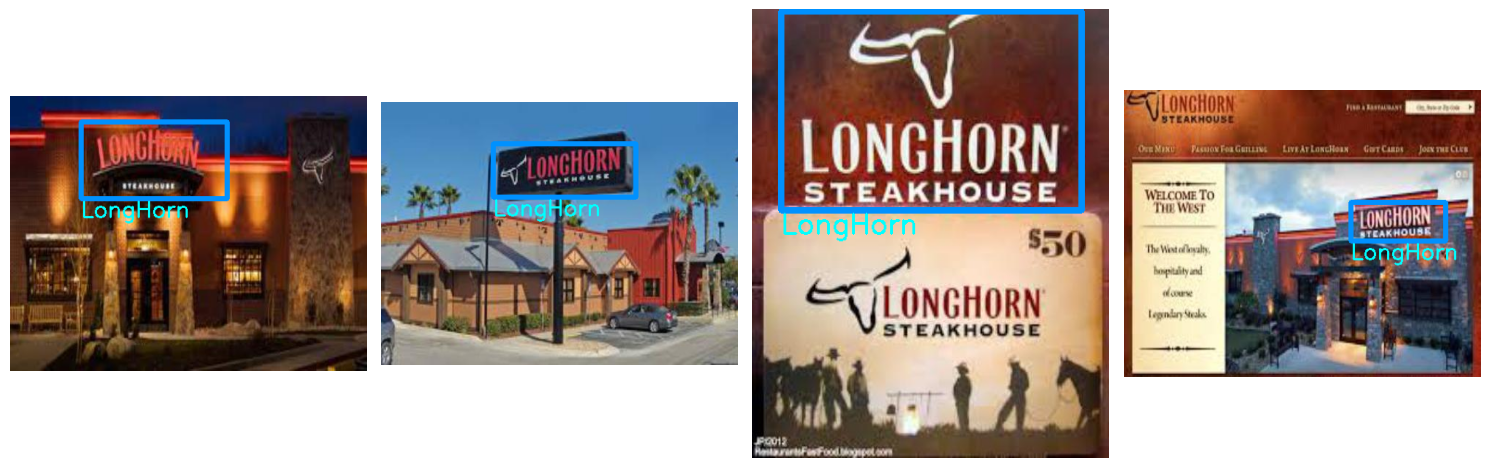

In [6]:
with open('./LOGO_DET/LOGO_DET_2.json', 'r') as f:
    annotations = json.load(f)

image_directory = "./LOGO_DET" 
show_boxes(image_directory, annotations)

Можно заметить что размечены не все лого, присутствующие на фото

## 3. Belga logos, FLickr32

Belga logos - Датасет 2007 года, содержащий около 10к реальных фотографий/кадров из видео. 37 классов логотипов.
FlickrLogos-32 2013г. Около 8к фотографий из сервиса Flickr. 32 класса
Оба были частично включены в OpenLogo

## 4. OpenLogo

Около 27к фотографий с очень разнообразными сценами. Есть перекос в сторону алкоголя. Собран из большого количества различных датасетов

FlickrLogo-32

WebLogo-2M

TopLogo-10

Flickr Logo 27

Logo32plus

BelgaLogos

Logos-In-The-Wild

SportsLogo

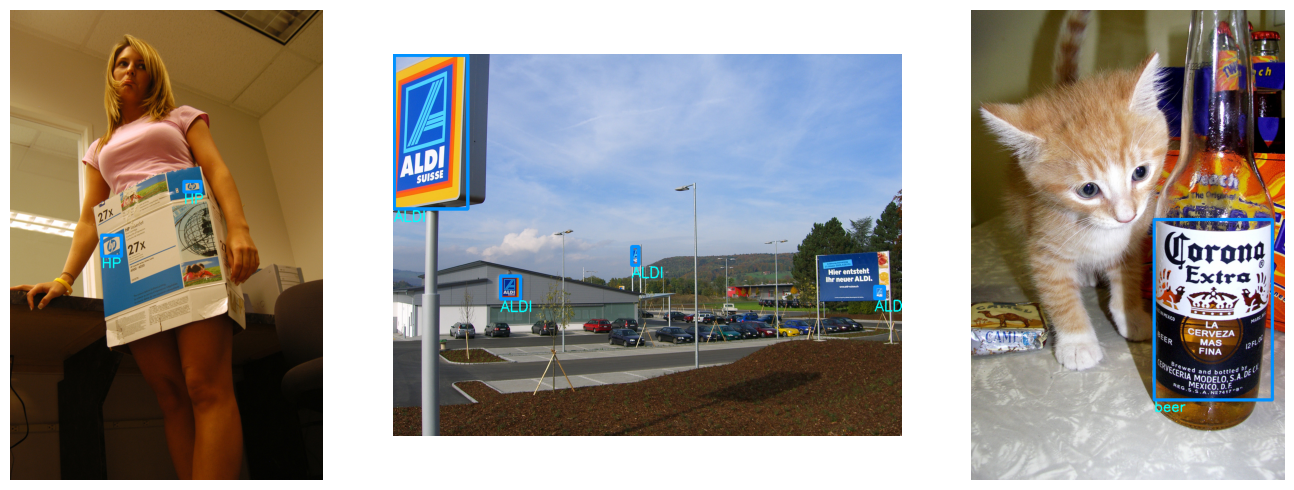

In [7]:
with open('./Openlogo/OPEN_LOGO.json', 'r') as f:
    annotations = json.load(f)

image_directory = "./Openlogo/" 
show_boxes(image_directory, annotations)

Присутствуют как фотографии где логотип занимает бОльшую часть изображения, так и фотографии с очень небольшими логотипами.

https://hangsu0730.github.io/qmul-openlogo/

## 5. Unsplash lite

Около 25к высококачественных фото. Можно использовать в качестве сложных сцен для фона

<table>
        <tr>
            <td style="width: 30%; text-align: center;"><img src="img/42.jpg""></td>
            <td style="width: 30%; text-align: center;"><img src="img/154.jpg""></td>
            <td style="width: 30%; text-align: center;"><img src="img/172.jpg""></td>
        </tr>
</table>

##  6. Kaggle - Large-scale Common Watermark Dataset

Размеченный датасет с 60к фото с наложенными на них водяными знаками. 

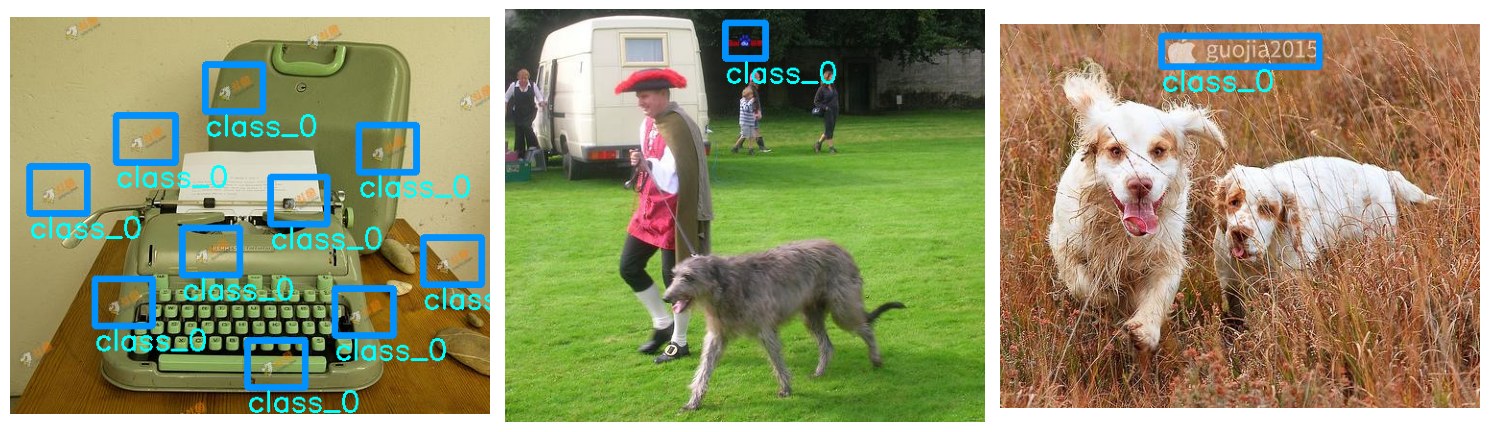

In [9]:
with open('./watermarks/annotations.json', 'r') as f:
    annotations = json.load(f)

image_directory = "./watermarks/" 
show_boxes(image_directory, annotations)

На знаках присутствуют логотипы, но разнообразие очень небольшое.

Обучение на реальных фотографиях с логотипами хотя и учит модель работать в "сложных" условиях, но все же потребует дообучения на приближенном к ожидаемым условиям датасете.

В качестве датасета последнего этапа для дообучения можно использовать реальные фотографии объявлений с авито (если будет возможность их получить) или случайные фото с добавлением на них аугментированных логотипов. Однако перед проведением дообучения стоит внести в описание прочие присутствующие
на фото логотипы. Для этого может потребуется ручная разметка.

При отсутствии фото с авито можно использовать, например датасеты 5 + наложение, 6

| 📊 Датасет | 📸 Изображений |  Классов | 📝 Особенности |
|------------|----------------|------------|---------------|
| **LogoDet-3K** | 158,652 | 3,000 |  Самый большой |
| **LCWD** | 60,000 | 1 |   Водяные знаки |
| **OpenLogo** | 27,000 | 352 |   Реалистичные,сборник |
| **OSLD** | 20,000 | 12,100+ |   Белый фон |
| **BelgaLogos** | 10,000 | 37 |   Реалистичные |
| **FlickrLogos-32** | 8,240 | 32 |Реалистичные, станд. бенчмарк|
| **Unsplash_lite** | 25000 | 0 |Реалистичные, высокое качество, нет разметки|

# Генерация датасета

Соберем пачку преимущественно российских логотипов

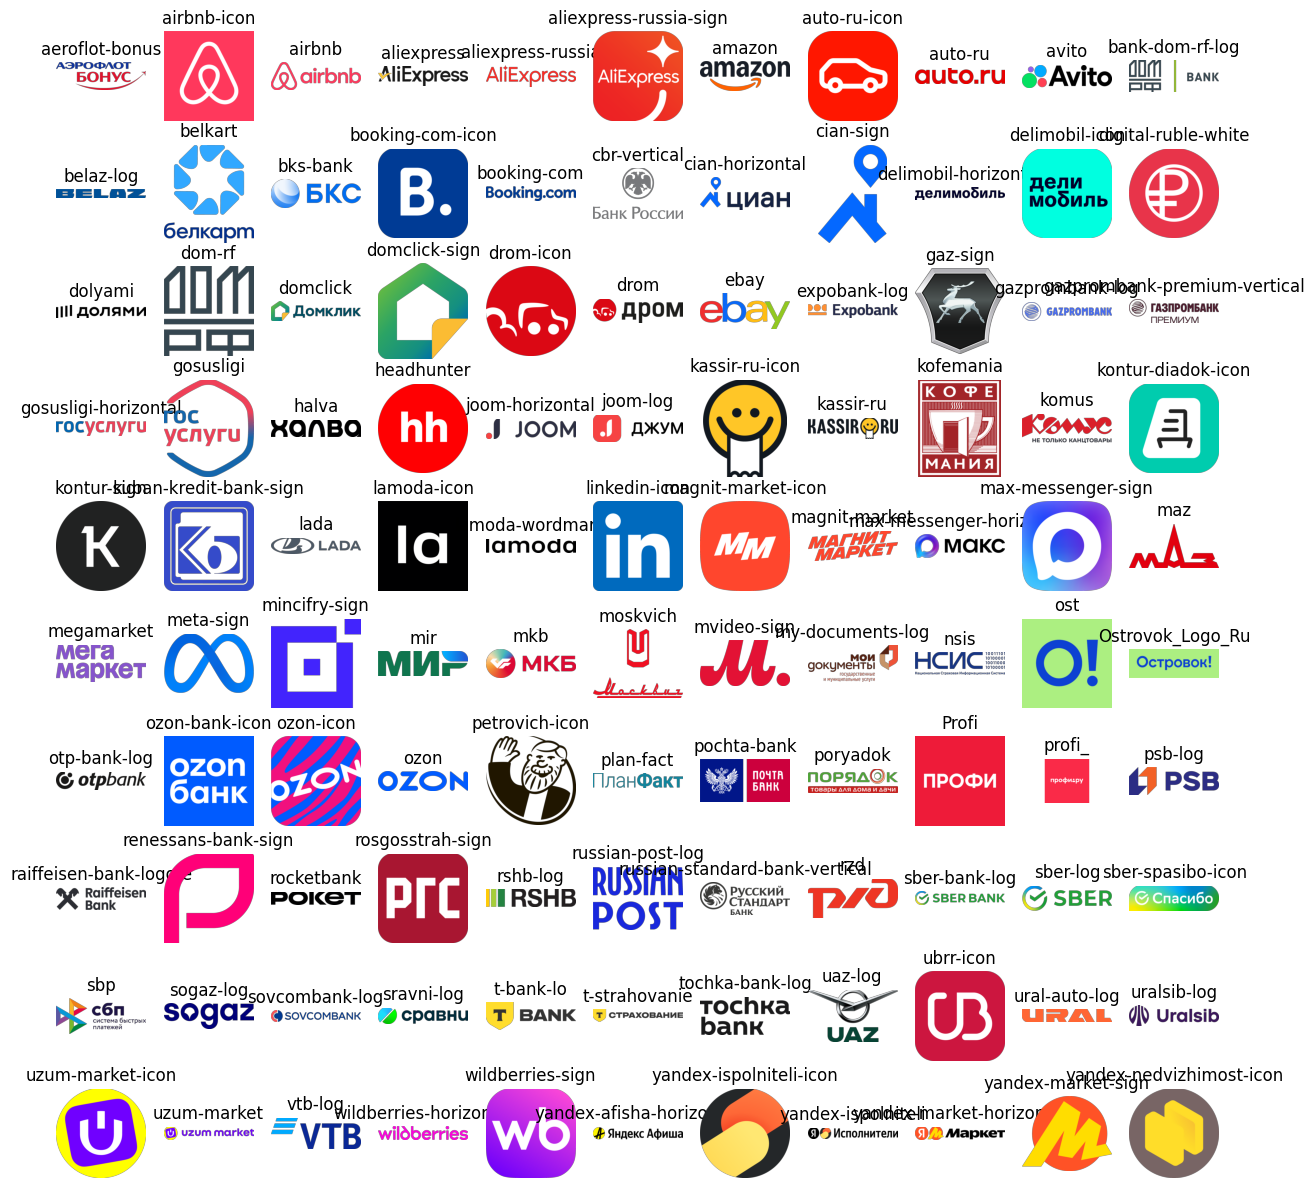

In [10]:
logos = os.listdir(r'./logos')
fig, axes =  plt.subplots(10, 11, figsize=(15,15))
def pic_reader(img_path):
    logo = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    alpha = np.ones((logo.shape[0], logo.shape[1], 1), dtype=logo.dtype) * 255
    logo_alpha = np.concatenate([logo, alpha], axis=2)  
    logo_rgba_alpha = logo_alpha[:, :, [2, 1, 0, 3]]
    return logo_rgba_alpha
    
for idx, ax in enumerate(axes.flat):
    ax.axis('off')
    result = pic_reader('./logos/' + logos[idx])
    ax.imshow(result)
    ax.set_title(logos[idx][:-9])
    

Функция помещающая логотип поверх фото. И чтоб крутилось!

In [11]:
def rotate_image(image, angle):
    """
    Поворачивает изображение 
    """
    h, w = image.shape[:2]
    center = (w // 2, h // 2)
    matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    
    cos = abs(matrix[0, 0])
    sin = abs(matrix[0, 1])
    new_w = int((h*sin) + (w*cos))
    new_h = int((h*cos) + (w*sin))
    
    matrix[0, 2] += (new_w / 2) - center[0]
    matrix[1, 2] += (new_h / 2) - center[1]
    
    rotated = cv2.warpAffine(image, matrix, (new_w, new_h), # Поворачиваем
                              flags=cv2.INTER_LINEAR, 
                              borderMode=cv2.BORDER_CONSTANT, 
                              borderValue=(0, 0, 0, 0))
    return rotated



def logo_adder(img_path, logo_path, opacity=1, logo_vs_im_size=0.41, w_color=True, angle=0, start_point=[0.5,0.5]):
    """
    Добавляет логотип поверх фото.
    Args:
        img_path - путь к изображению
        logo_path - путь к логотипу
        opacity - прозрзачность
        logo_vs_im_size = ширина лого / ширина изображения
        w_color - делаем цвет логотипа белым
        angle - угол поворота
        start_point [0:1, 0:1] - расположение лого
    """
    background = pic_reader(img_path)
    back_height, back_width = background.shape[:2]
    foreground = pic_reader(logo_path)
    for_height, for_width = foreground.shape[:2]
    
    if w_color:  # Делаем белым
        if foreground.shape[2] == 4:
            alpha = foreground[:, :, 3]
        else:
            alpha = np.ones((for_height, for_width)) * 255
        white_logo = np.ones((for_height, for_width, 3)) * 255
        foreground = np.concatenate([white_logo, alpha[:, :, np.newaxis]], axis=2)
    
    new_for_width = int(back_width * logo_vs_im_size)
    new_for_height = int(new_for_width * for_height / for_width)
    foreground_resized = cv2.resize(foreground, (new_for_width, new_for_height))
    print(foreground_resized.shape)
    
    if angle != 0:  # Поворот
        foreground_resized = rotate_image(foreground_resized, angle)
        new_for_height, new_for_width = foreground_resized.shape[:2] # Обновляем размеры
    # print(new_for_height, new_for_width)
    alpha = foreground_resized[:, :, 3] / 255.0 * opacity
    start_x = int(back_width * start_point[0])
    start_y = int(back_height * start_point[1])
        
    if start_x + new_for_width > back_width: # Обрезаем лого если выходит за пределы
        new_for_width = back_width - start_x
        foreground_resized = foreground_resized[:, :new_for_width]
        alpha = alpha[:, :new_for_width]
    
    if start_y + new_for_height > back_height:
        new_for_height = back_height - start_y
        foreground_resized = foreground_resized[:new_for_height, :]
        alpha = alpha[:new_for_height, :]
    # print(new_for_height, new_for_width)
    
    for c in range(3):
        background[start_y:start_y + new_for_height, # ширина
                   start_x:start_x + new_for_width, c] = \
            background[start_y:start_y + new_for_height, 
                       start_x:start_x + new_for_width, c] * (1 - alpha) + \
            foreground_resized[:, :, c] * alpha
    bbox = [start_point[0], start_point[1], np.clip(start_point[0] + (new_for_width/back_width), 0,1),
            np.clip(start_point[1] + (new_for_height/back_height), 0, 1)]
    return [background, bbox]


## Смотрим что получилось

(48, 256, 4)


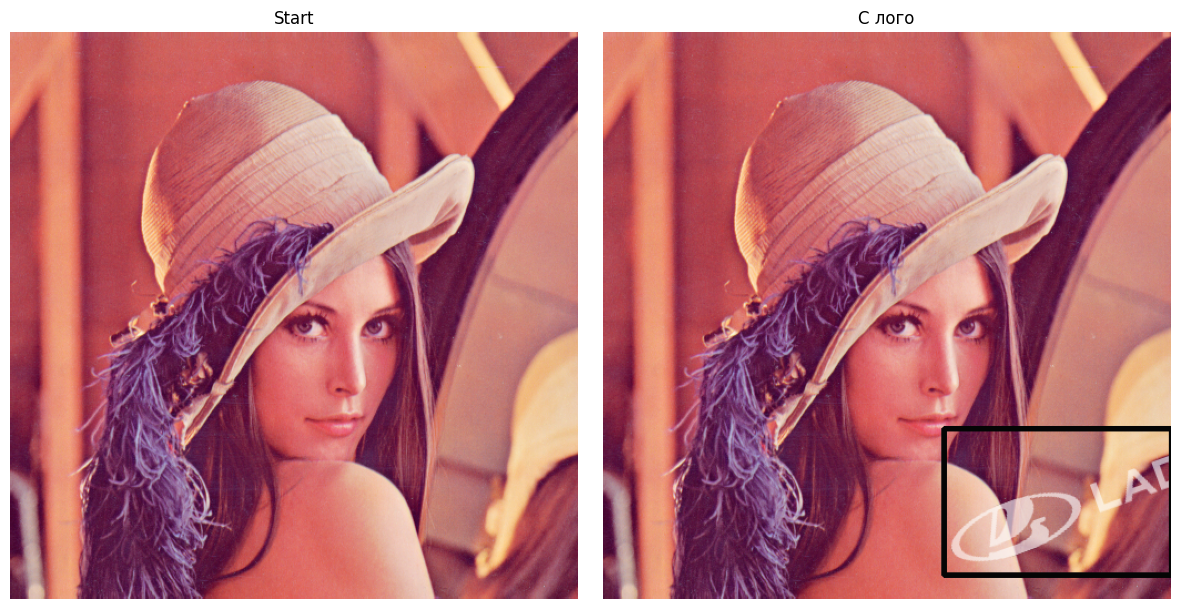

In [ ]:
pic, bbox = logo_adder('./img/Lenna.png', './logos/lada-logo.png',w_color=True, logo_vs_im_size=0.5, start_point=[0.6,0.7], opacity=0.62, angle = 20)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

original = pic_reader('./img/Lenna.png')
axes[0].imshow(original)
axes[0].set_title('Start')
axes[0].axis('off')

h, w = pic.shape[:2]
x1, y1, x2, y2 = [int(bbox[0]*w), int(bbox[1]*h), int(bbox[2]*w), int(bbox[3]*h)]

# Рисуем рамку
result_with_box = pic.copy()
cv2.rectangle(result_with_box, (x1, y1), (x2, y2), (0, 0, 0, 250), 3)

axes[1].imshow(result_with_box)
axes[1].set_title('С лого')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Или воспользуемся albumentations для искажения логотипа перед нанесением

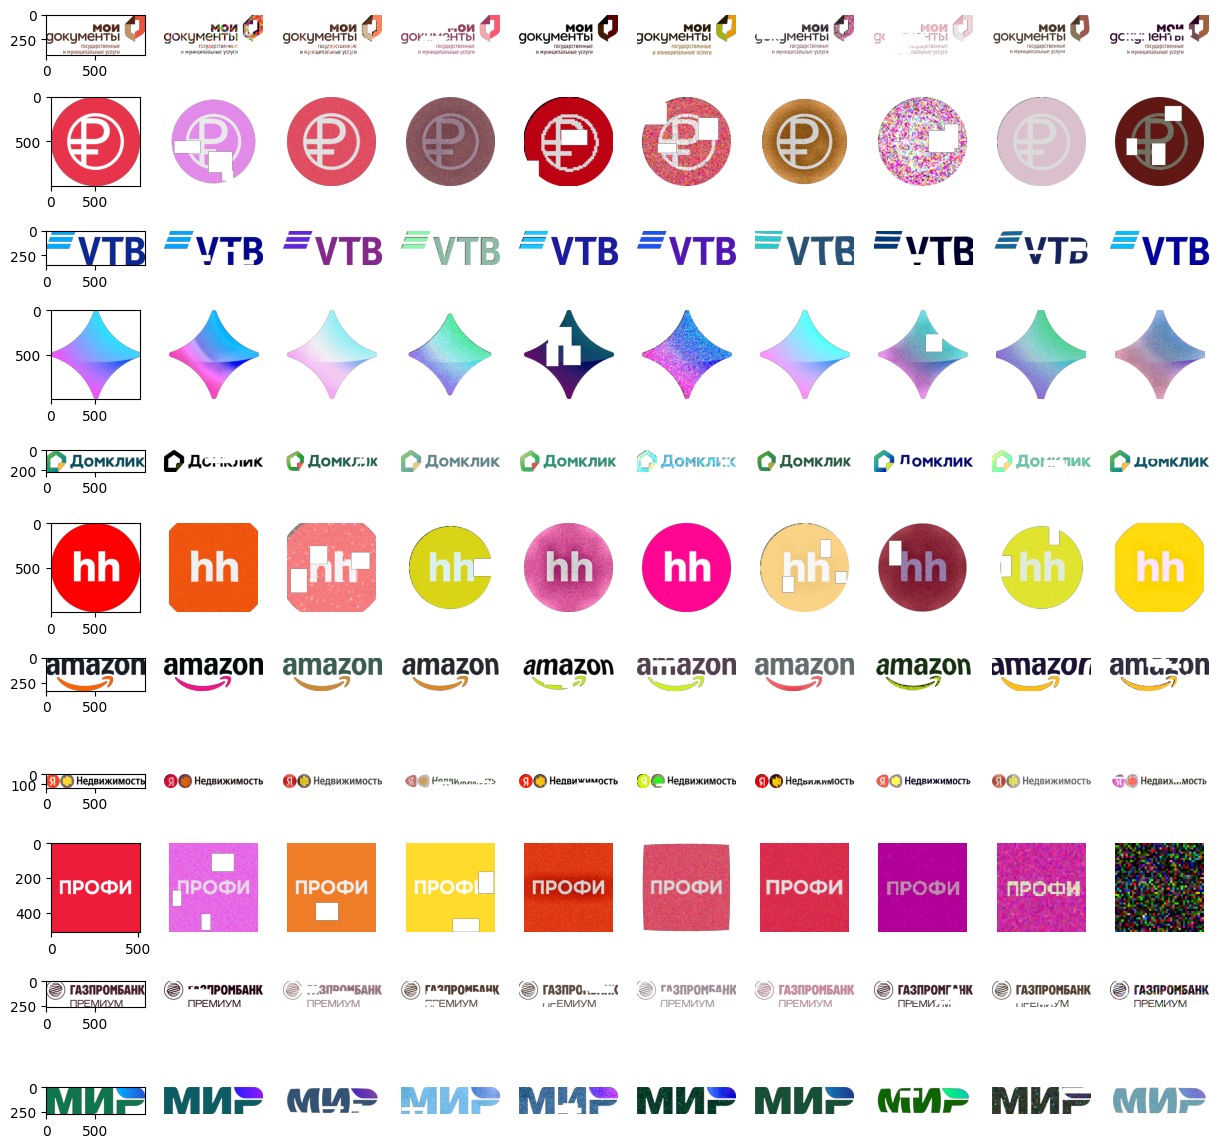

In [13]:
import albumentations as A

logos = os.listdir(r'./logos')
def change_logo(logo_path):
    """
    Применяет аугментации к лого
    """
    logo = cv2.imread(logo_path, cv2.IMREAD_UNCHANGED)
    
    # RGB и Alpha
    if logo.shape[2] == 4:
        rgb = logo[:, :, :3]
        alpha = logo[:, :, 3]
    else:
        rgb = logo
        alpha = np.ones((logo.shape[0], logo.shape[1])) * 255
    
    # Конвертируем в RGB 
    rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
    
    transform = A.Compose([
        # Цвет
        A.RandomBrightnessContrast(brightness_limit=0.5, contrast_limit=0.5, p=0.8),
        A.HueSaturationValue(hue_shift_limit=30, sat_shift_limit=50, val_shift_limit=30, p=0.7),
        A.RandomGamma(gamma_limit=(70, 130), p=0.6),
        A.RGBShift(r_shift_limit=30, g_shift_limit=30, b_shift_limit=30, p=0.5),
        
        # Шум
        A.GaussNoise(std_range=(0.1,0.4), p=0.5),
        A.GaussianBlur(blur_limit=(3, 7), p=0.4),
        A.ISONoise(color_shift=(0.05, 0.2), intensity=(0.2, 0.5), p=0.4),
        
        A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
        A.Downscale(scale_range=(0.05, 0.2), p=0.3),  
         
        A.OpticalDistortion(distort_limit=0.4, p=0.5, border_mode=cv2.BORDER_CONSTANT),
        # имитация перекрытия
        A.CoarseDropout(
            num_holes_range=(1, 3),
            hole_height_range=(0.1, 0.3),
            hole_width_range=(0.1, 0.3),
            fill=0,
            fill_mask=0,  
            p=0.5
        ),

    
        # Геом
        # A.Rotate(limit=20, p=0.5),
    ])



    augmented = transform(image=rgb, mask=alpha)
    rgb_aug = augmented['image']
    alpha_aug = augmented['mask']
    alpha_aug = alpha_aug.astype(np.uint8)
    
    result = np.concatenate([rgb_aug, alpha_aug[:, :, np.newaxis]], axis=2)
    return result



fig, axes =  plt.subplots(11, 10, figsize=(15,15))  
for idx, ax in enumerate(axes.flat):
    if idx % 10 == 0:
        new_logo = random.choice(logos)
        result = pic_reader('./logos/' + new_logo)
    else:
        result = change_logo('./logos/' + new_logo)
        ax.axis('off')
    ax.imshow(result)
 

с цветами и перекрытием как будто перебор:)

## Посмотрим как вместе работает

In [14]:
# os.mkdir(r'./test_lada_logo')
for i in range(20):
    res = change_logo(r'./logos/lada-logo.png')
    cv2.imwrite(f'./test_lada_logo/output_logo_{str(i)}.png', res)

(48, 256, 4)


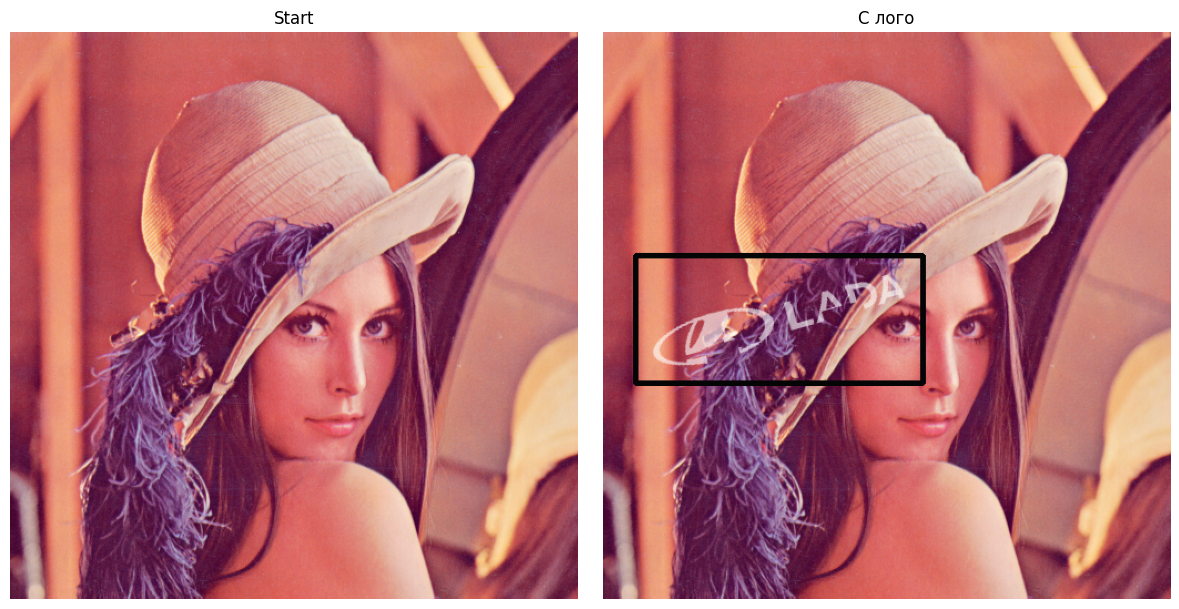

In [ ]:
random_logo = random.choice(os.listdir('./test_lada_logo/'))
logo_path = f'./test_lada_logo/{random_logo}'

pos_x=random.uniform(0,0.8)
pos_y=random.uniform(0.1,0.8)
angle=random.uniform(-30,30)

pic, bbox = logo_adder('./img/Lenna.png', logo_path, w_color=True, logo_vs_im_size=0.5, start_point=[pos_x, pos_y], opacity=0.62, angle=angle)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

original = pic_reader('./img/Lenna.png')
axes[0].imshow(original)
axes[0].set_title('Start')
axes[0].axis('off')

h, w = pic.shape[:2]
x1, y1, x2, y2 = [int(bbox[0]*w), int(bbox[1]*h), int(bbox[2]*w), int(bbox[3]*h)]

# Рисуем рамку
result_with_box = pic.copy()
cv2.rectangle(result_with_box, (x1, y1), (x2, y2), (0, 0, 0, 250), 3)

axes[1].imshow(result_with_box)
axes[1].set_title('С лого')
axes[1].axis('off')

plt.tight_layout()
plt.show()